#setup


In [ ]:
!pip install nilearn --quiet

import os
import re
import tarfile
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

#Load Data

In [ ]:
# parameter setting
N_SUBJECTS = 100
N_PARCELS = 360 # Data aggregated into ROIs from Glasser parcellation
TR = 0.72  # Time resolution, in seconds
HEMIS = ["Right", "Left"]
RUNS   = ["LR","RL"]
N_RUNS = 2

EXPERIMENTS = {
    'MOTOR'      : {'cond':['lf','rf','lh','rh','t','cue']},
    'WM'         : {'cond':['0bk_body','0bk_faces','0bk_places','0bk_tools',
                            '2bk_body','2bk_faces','2bk_places','2bk_tools']},
    'EMOTION'    : {'cond':['fear','neut']},
    'GAMBLING'   : {'cond':['loss','win']},
    'LANGUAGE'   : {'cond':['math','story']},
    'RELATIONAL' : {'cond':['match','relation']},
    'SOCIAL'     : {'cond':['ment','rnd']}
}

TargetExperiments = ['WM']

TargetConditions  = ["0bk_body", "0bk_faces", "0bk_places", "0bk_tools",
                     "2bk_body", "2bk_faces", "2bk_places", "2bk_tools",
                     "fear"    , "neut"     , "math"      , "story"    ]

# Data download
fname = "hcp_task.tgz"
url = "https://osf.io/2y3fw/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("Download FAILED: Connection Error!")
  else:
    if r.status_code != requests.codes.ok:
      print("Download FAILED!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)


HCP_DIR = "./hcp_task"

with tarfile.open(fname) as tfile:
  tfile.extractall('.')

SubjectIDs = np.loadtxt(os.path.join(HCP_DIR, 'subjects_list.txt'), dtype='str')
SubjectIDs = list(SubjectIDs)

In [ ]:
print(len(SubjectIDs))

100


In [ ]:
subject_id = "100307"
subject_path = os.path.join(HCP_DIR, "subjects", subject_id)
print(os.listdir(subject_path))

['RELATIONAL', 'WM', 'MOTOR', 'GAMBLING', 'EMOTION', 'LANGUAGE', 'SOCIAL']


In [ ]:
### doc about the regions file will be inserted (look at regions.npy)

regions = np.load(f"{HCP_DIR}/regions.npy").T

region_info = dict(
    name=regions[0].tolist(),
    network=regions[1],
    hemi=['Right']*int(N_PARCELS/2) + ['Left']*int(N_PARCELS/2),
)


### code will be updated

#Helper Functions

In [ ]:
# load time series
def load_single_timeseries(subject, experiment, run, remove_mean=True):
    """Load timeseries data for a single subject and single run.

    Arguments:
        subject (str):      subject ID to load
        experiment (str):   Name of experiment
        run (int):          (0 or 1)
        remove_mean (bool): If True, subtract the parcel-wise mean
                            (typically the mean BOLD signal is not of interest)

    Returns
        ts (n_parcel x n_timepoint array): Array of BOLD data values

    """
    bold_run  = RUNS[run]
    bold_path = f"{HCP_DIR}/subjects/{subject}/{experiment}/tfMRI_{experiment}_{bold_run}"
    bold_file = "data.npy"
    ts_path   = f"{bold_path}/{bold_file}"

    if not os.path.exists(ts_path):
        raise FileNotFoundError(f"Timeseries file not found: {ts_path}")
    ts = np.load(ts_path)

    if remove_mean:
        ts = ts - ts.mean(axis=1, keepdims=True)
    return ts

In [ ]:
# load evs
def load_evs(subject, experiment, run):
    """Load EVs (explanatory variables) data for one task experiment.

    Arguments:
        subject (str): subject ID to load
        experiment (str): Name of experiment
        run (int): 0 or 1

    Returns:
        evs (list of lists): A list of frames associated with each condition

    """
    frames_list = []
    task_key = f"tfMRI_{experiment}_{RUNS[run]}"
    for cond in EXPERIMENTS[experiment]["cond"]:
        ev_file  = f"{HCP_DIR}/subjects/{subject}/{experiment}/{task_key}/EVs/{cond}.txt"
        ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
        ev       = dict(zip(["onset", "duration", "amplitude"], ev_array))

        # Determine when trial starts, rounded down
        start = np.floor(ev["onset"] / TR).astype(int)
        # Use trial duration to determine how many frames to include for trial
        duration = np.ceil(ev["duration"] / TR).astype(int)
        # Take the range of frames that correspond to this specific trial
        frames = [s + np.arange(0, d) for s, d in zip(start, duration)]
        frames_list.append(frames)

    return frames_list


def load_evs_as_dict(subject, experiment, run):
    """Load EVs (explanatory variables) data for one task experiment.

    Arguments:
        subject (str): subject ID to load
        experiment (str): Name of experiment
        run (int): 0 or 1

    Returns:
        evs (dict): A dictionary of the data associated with each condition

    """
    evs = {}
    task_key = f"tfMRI_{experiment}_{RUNS[run]}"

    for cond  in EXPERIMENTS[experiment]["cond"]:
        ev_file = f"{HCP_DIR}/subjects/{subject}/{experiment}/{task_key}/EVs/{cond}.txt"
        if not os.path.exists(ev_file):
            raise FileNotFoundError(f"EV file not found: {ev_file}")
        ev_array  = np.loadtxt(ev_file, ndmin=2, unpack=True)
        evs[cond] = dict(zip(["onset", "duration", "amplitude"], ev_array))

    return evs

In [ ]:
# create data frame
def create_dataframe(subject, experiment):
    """
    Creates a dataframe that contains the parcel-based
    BOLD signals from a subject for each condition.

    Arguments:
        subject (str): subject ID to load
        experiment (str): Name of experiment

    Returns:
        A dataframe of parcel-based BOLD data
        for one subject and one experiment

    """
    all_data = []

    for run in range(2): # Run can be 0 (LR) or 1 (RL)
        try:
            ts  = load_single_timeseries(subject, experiment, run)
            evs = load_evs_as_dict(subject, experiment, run)
        except FileNotFoundError as e:
            print(e)
            continue

        n_parcels, n_timepoints = ts.shape

        for condition, ev_data in evs.items():
            onset_times = ev_data["onset"]
            durations   = ev_data["duration"]
            amplitudes  = ev_data["amplitude"]

            for onset, duration, amplitude in zip(onset_times, durations, amplitudes):
                start_frame = int(onset / TR)
                end_frame   = start_frame + int(duration / TR)

                for time_point in range(start_frame, end_frame):
                    if time_point < n_timepoints: # Ensure it is within bounds
                        row = {
                            "subject"      : subject   ,
                            "experiment"   : experiment,
                            "run"          : RUNS[run] ,
                            "condition"    : condition ,
                            "timepoint"    : time_point,
                            "EV_onset"     : onset     ,
                            "EV_duration"  : duration  ,
                            "EV_amplitude" : amplitude
                        }
                        # Add BOLD signal data for all parcels
                        row.update({f"parcel_{i}": ts[i, time_point] for i in range(n_parcels)})
                        all_data.append(row)

    df = pd.DataFrame(all_data) #all_data = all data of one subject
    return df

In [ ]:
def extract_stats(subject, experiment):
    """Aggregates all data for a subject into
    a dictionary that can be used along with
    "gather_all_subjects_stats()" to create
    the final dataframe.

    Arguments:
        subjects    (list of str): list of SubjectIDs
        experiments (list of str): list of TargetExperiments

    Returns:
        A dictionary of all the data points
        for a subject's specific experiment.


    """
    stats_dict = {"subject": subject}
    task_path  = f"{HCP_DIR}/subjects/{subject}/{experiment}/tfMRI_{experiment}_LR/EVs"

    if os.path.exists(task_path):
        for filename in os.listdir(task_path):
            if filename == "Stats.txt":
                filepath = os.path.join(task_path, filename)
                with open(filepath, "r") as file:
                    lines = file.readlines()
                    for line in lines:
                        match = re.match(r"([\w\s-]+): ([\d.]+)", line.strip())
                        if match:
                            key, value = match.groups()
                            stats_dict[f"{experiment}_{key.strip().replace(' ', '_')}"] = float(value)

    return stats_dict

In [ ]:
def gather_all_subjects_stats(subjects, experiments):
    """Creates a dataframe containing all data from
    all subjects which stores the parcel-based BOLD signals.

    Arguments:
        subjects    (list of str): list of SubjectIDs
        experiments (list of str): list of TargetExperiments

    Returns:
        A dataframe of parcel-based BOLD data
        for all subjects and all experiments

    """
    all_stats = []

    for subject in subjects:
        subject_stats = {"subject": subject}
        for experiment in experiments:
            stats = extract_stats(subject, experiment)
            subject_stats.update(stats)

            # Get the dimensions of DataFrame for this subject and experiment
            try:
                df = create_dataframe(subject, experiment)
                subject_stats[f"{experiment}_num_rows"] = df.shape[0]
                subject_stats[f"{experiment}_num_cols"] = df.shape[1]
            except FileNotFoundError:
                subject_stats[f"{experiment}_num_rows"] = None
                subject_stats[f"{experiment}_num_cols"] = None

        all_stats.append(subject_stats)

    stats_df = pd.DataFrame(all_stats)
    return stats_df

In [ ]:
def save_stats_to_csv(df, filename):
    """Saves the input dataframe as a csv in working directory.

    Arguments:
        df (dataframe)
        filename (str)
    """
    df.to_csv(filename, index=False)

In [ ]:
def save_to_csv(df, output_folder, filename):
    """Saves the input dataframe as a csv in
    output_folder of working directory.

    Arguments:
        df      (dataframe)
        output_folder (str)
        filename      (str)
    """
    file_path = os.path.join(output_folder, filename)
    df.to_csv(file_path, index=False)

In [ ]:
def process_subject(subject, experiments, output_folder):
    """
    ????????
    Works with create_dataframe() and save_tocsv() functions.

    Arguments:

    Returns:
        List of dataframes.
    """
    all_dfs = []

    for experiment in experiments:
        df = create_dataframe(subject, experiment)
        if not df.empty:
            all_dfs.append(df)
        else:
            print(f"No data to save for subject {subject}, experiment {experiment}.")

        # Concatenate all dataframes row-wise
        if all_dfs:
            final_df = pd.concat(all_dfs, axis = 0)
            save_to_csv(final_df, output_folder, f"{subject}_data.csv")
        else:
            print(f"No data to save for subject {subject}.")

    return

#Create data frame


In [ ]:
# create grand dataframe for all subjects
output_folder = "./wm_csv_files"
os.makedirs(output_folder, exist_ok = True)

for subject in SubjectIDs:
    process_subject(subject, TargetExperiments, output_folder)

In [ ]:
file_list = os.listdir(output_folder)

for filename in file_list:
  filepath = os.path.join(output_folder, filename)
  df = pd.DataFrame()  # Create an empty dataframe
  df = pd.read_csv(filepath)  # Load data from CSV (overwrites the empty dataframe)
  # Perform your desired manipulations on the dataframe (df) here


#Design Matrix and parcellated BOLD time series array



In [ ]:
#2D array - parcellated BOLD timeseries
subj_100307 = pd.read_csv("./wm_csv_files/100307_data.csv")
subj_100307
subj_100307 = load_single_timeseries('100307', 'WM', 0, remove_mean=True)
print(subj_100307.shape)

(360, 405)


In [ ]:
import nilearn
import nibabel as nib
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
from nilearn.signal import clean

In [ ]:
t_r = 0.72
n_scans = subj_100307.shape[1]
print(f"repetition time is {t_r} second")
print(f"the acquisition comprises {n_scans} scans")
frame_times = np.arange(n_scans) * t_r

conditions = df["condition"]
duration = df["EV_duration"]
onsets = df['EV_onset']

events = pd.DataFrame({'trial_type': conditions, 'onset': onsets, 'duration': duration})
events

repetition time is 0.72 second
the acquisition comprises 405 scans


,trial_type,onset,duration
0,0bk_body,38.664,27.5
1,0bk_body,38.664,27.5
2,0bk_body,38.664,27.5
3,0bk_body,38.664,27.5
4,0bk_body,38.664,27.5
...,...,...,...
603,2bk_tools,81.900,27.5
604,2bk_tools,81.900,27.5
605,2bk_tools,81.900,27.5
606,2bk_tools,81.900,27.5


/usr/local/lib/python3.11/dist-packages/nilearn/glm/first_level/experimental_paradigm.py:208: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  warnings.warn(


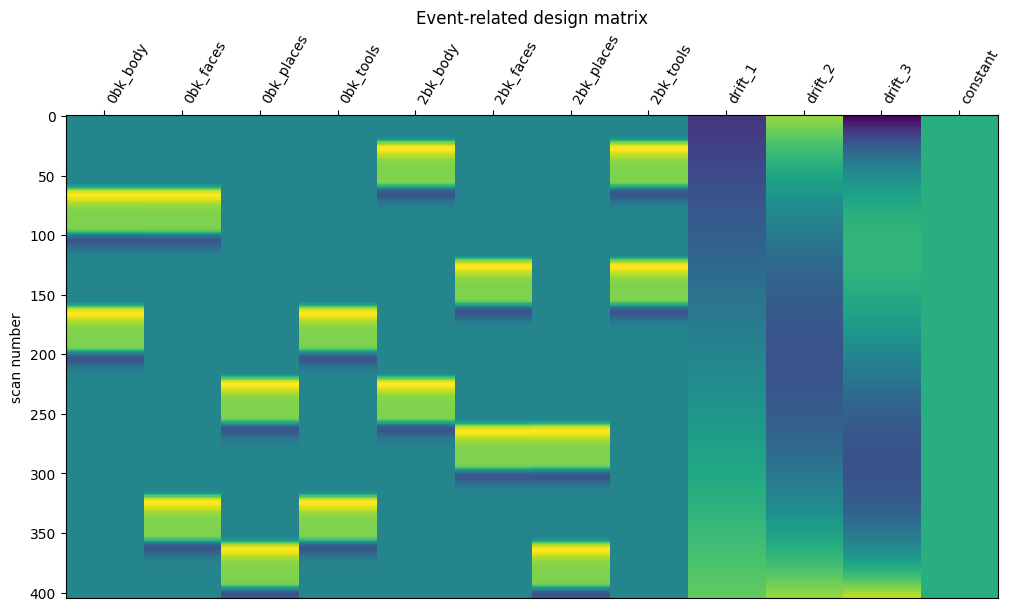

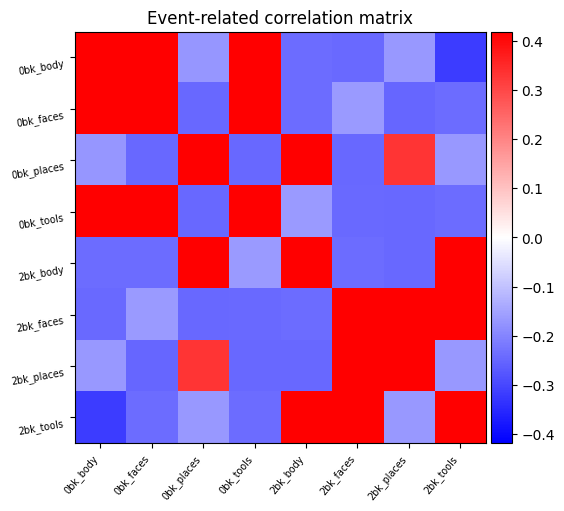

In [ ]:
#event-related design matrix
from nilearn.glm.first_level import make_first_level_design_matrix
design_matrices = make_first_level_design_matrix(frame_times, events,
                          drift_model='polynomial', drift_order=3)

import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix
fig, (ax1) = plt.subplots(
    figsize=(10, 6), nrows=1, constrained_layout=True
)

plot_design_matrix(design_matrices, axes=ax1)
ax1.set_title("Event-related design matrix", fontsize=12)
plt.show()

from nilearn.plotting import plot_design_matrix_correlation
fig, (ax1) = plt.subplots(
    figsize=(16, 5), nrows=1, constrained_layout=True
)

plot_design_matrix_correlation(design_matrices, axes=ax1)
ax1.set_title("Event-related correlation matrix", fontsize=12)
plt.show()


In [ ]:
print(design_matrices.shape)
print(subj_100307.shape) #x=parcel, y = n_scan
print(df.shape) ##608 should be the event/trail number - not the n_scan

(405, 12)
(360, 405)
(608, 368)


In [ ]:
reshape_subj_100307 = np.transpose(subj_100307)
print(reshape_subj_100307.shape)

(405, 360)


In [ ]:
from nilearn.glm.first_level import run_glm
labels, results = run_glm(reshape_subj_100307, design_matrices, noise_model='ar1')

print(len(results))

78


In [ ]:
fmri_glm_first_level_first_level = nilearn.glm.first_level.run_glm(Y = reshape_subj_100307, X = design_matrices) # try this!!

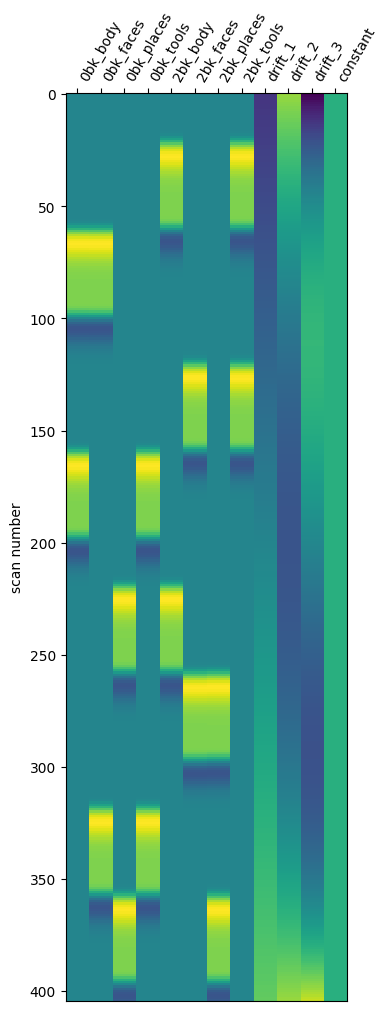

In [ ]:
from nilearn.plotting import plot_design_matrix

plot_design_matrix(design_matrices)
import matplotlib.pyplot as plt

plt.show()

#Contrasts



In [ ]:
 def make_localizer_contrasts(design_matrices):
  """Return a dictionary of contrasts, given the design matrix."""
  # first generate canonical contrasts
  contrast_matrix = np.eye(design_matrices.shape[1])
  contrasts = {
      column: contrast_matrix[i]
      for i, column in enumerate(design_matrices.columns)
  }

  # Contrasts for WM experiment conditions
  contrasts = {
        "0bk_body - 2bk_body": contrasts["0bk_body"] - contrasts["2bk_body"],
        "0bk_places - 2bk_places": contrasts["0bk_places"] - contrasts["2bk_places"],
        "0bk_tools - 2bk_tools": contrasts["0bk_tools"] - contrasts["2bk_tools"],
        "0bk_faces - 2bk_faces": contrasts["0bk_faces"] - contrasts["2bk_faces"],
    }
  return contrasts # Corrected indentation

In [ ]:
# Compute contrast results
def compute_contrast(results, contrasts):
    """Compute contrast maps for each parcel."""
    contrast_maps = {}

    for contrast_id, contrast_val in contrasts.items():
        contrast_maps[contrast_id] = [
            results[i].compute_contrast(contrast_val, output_type="z_score")
            for i in range(len(results))  # Loop over parcels
        ]

    return contrast_maps

In [ ]:
# Compute contrast results
def compute_contrast(results, contrasts):
    """Compute contrast maps for each parcel."""
    contrast_maps = {}

    for contrast_id, contrast_val in contrasts.items():
        contrast_maps[contrast_id] = [
            # The results dictionary is keyed by parcel labels, not indices.
            # Iterate through the keys of the results dictionary:
            results[parcel_label].compute_contrast(contrast_val, output_type="z_score")
            for parcel_label in results  # Loop over parcel labels in results
        ]

    return contrast_maps

In [ ]:
def compute_contrast(results, contrasts, design_matrices):
    """Manually compute contrast maps for each parcel, ensuring correct regressor selection."""
    contrast_maps = {}

    for contrast_id, contrast_val in contrasts.items():
        # Extract only the first `design_matrices.shape[1]` coefficients (task-related)
        relevant_thetas = {
            parcel_label: results[parcel_label].theta[:design_matrices.shape[1]]
            for parcel_label in results
        }

        # Compute contrasts
        contrast_maps[contrast_id] = [
            np.dot(contrast_val, relevant_thetas[parcel_label].flatten())
            for parcel_label in results  # Loop over parcels
        ]

    return contrast_maps


In [ ]:
contrasts = make_localizer_contrasts(design_matrices)
# contrast_maps = compute_contrast(results, contrasts, design_matrices)

print(type(results))
# contrasts.shape()
#

# Plot bar plots for per-parcel contrast results
plot_contrast_parcellated(contrast_maps)


<class 'dict'>


NameError: name 'contrast_maps' is not defined

In [ ]:
# Compute contrasts for the dataset
contrasts = make_localizer_contrasts(design_matrices)
contrast_maps = compute_contrast(results, contrasts)

# Plot contrast matrices for design visualization
plt.figure(figsize=(12, 6))
for idx, (key, values) in enumerate(contrasts.items()):
    plt.subplot(2, 2, idx + 1)
    plot_contrast_matrix(values, design_matrix=design_matrices)
    plt.title(key)
plt.tight_layout()
plt.show()

ValueError: shapes (12,) and (24,) not aligned: 12 (dim 0) != 24 (dim 0)

In [ ]:
# Function to plot per-parcel contrast results
def plot_contrast_parcellated(contrast_maps):
    """Plot bar plots for contrast results from parcellated time-series data."""

    plt.figure(figsize=(20, 5))

    for index, (contrast_id, z_maps) in enumerate(contrast_maps.items()):
        ax = plt.subplot(1, len(contrast_maps), index + 1)
        avg_z_map = np.mean(z_maps)  # Average across parcels

        # Bar plot visualization
        plt.bar(range(len(z_maps)), z_maps, alpha=0.7)
        plt.axhline(y=3.0, color="r", linestyle="--")  # Mark threshold
        plt.title(contrast_id)
        plt.xlabel("Parcels")
        plt.ylabel("Z-score")

    plt.show()

# Plot computed contrasts for parcels
plot_contrast_parcellated(contrast_maps)

NameError: name 'contrast_maps' is not defined

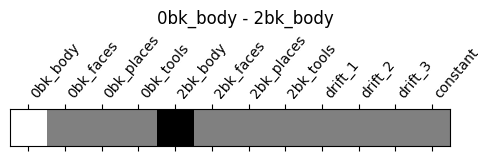

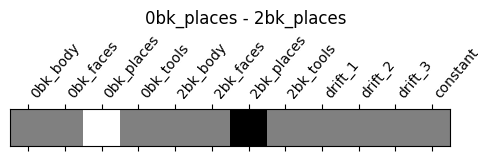

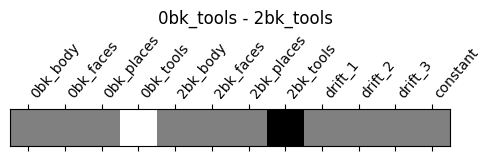

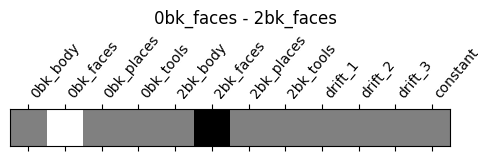

In [ ]:
# Let's look at these computed contrasts:
#
# * 'left - right button press': probes motor activity
#   in left versus right button presses
# * 'horizontal-vertical': probes the differential activity
#   in viewing a horizontal vs vertical checkerboard
# * 'audio - visual': probes the difference of activity
#   between listening to some content or reading
#   the same type of content (instructions, stories)
# * 'computation - sentences': looks at the activity
#   when performing a mental comptation task
#   versus simply reading sentences.
#
from nilearn.plotting import plot_contrast_matrix

contrasts = make_localizer_contrasts(design_matrices)

for key, values in contrasts.items():
    plot_contrast_matrix(values, design_matrix=design_matrices)
    plt.suptitle(key)

plt.show()

In [ ]:
# A first contrast estimation and plotting
# ----------------------------------------
#
# As this script will be repeated several times, we encapsulate model
# fitting and plotting in a function that we call when needed.
#
from nilearn import plotting
def plot_contrast(fmri_glm_first_level):
    """Specify, estimate and plot the main contrasts \
        for given a first model.
    """
    design_matrix = fmri_glm_first_level.design_matrices_[0]
    # Call the contrast specification within the function
    contrasts = make_localizer_contrasts(design_matrix)
    plt.figure(figsize=(20, 4))
    # compute the per-contrast z-map
    for index, (contrast_id, contrast_val) in enumerate(contrasts.items()):
        ax = plt.subplot(1, len(contrasts), 1 + index)
        z_map = fmri_glm_first_level.compute_contrast(
            contrast_val, output_type="z_score"
        )
        plotting.plot_stat_map(
            z_map,
            display_mode="z",
            threshold=3.0,
            title=contrast_id,
            axes=ax,
            cut_coords=1,
        )

# Let's run the model and look at the outcome.

plot_contrast(fmri_glm_first_level)
plt.show()


NameError: name 'fmri_glm_first_level' is not defined

In [ ]:
print(type(fmri_glm_first_level))


<class 'tuple'>


In [ ]:
print(results)

{np.str_('-0.01'): <nilearn.glm.regression.RegressionResults object at 0x7db25d8e8c50>, np.str_('-0.03'): <nilearn.glm.regression.RegressionResults object at 0x7db25e3730d0>, np.str_('-0.04'): <nilearn.glm.regression.RegressionResults object at 0x7db25d74fd10>, np.str_('-0.05'): <nilearn.glm.regression.RegressionResults object at 0x7db25e3b41d0>, np.str_('-0.06'): <nilearn.glm.regression.RegressionResults object at 0x7db25d74d5d0>, np.str_('-0.09'): <nilearn.glm.regression.RegressionResults object at 0x7db25d617c90>, np.str_('0.0'): <nilearn.glm.regression.RegressionResults object at 0x7db25d615910>, np.str_('0.02'): <nilearn.glm.regression.RegressionResults object at 0x7db25d6144d0>, np.str_('0.03'): <nilearn.glm.regression.RegressionResults object at 0x7db25d6175d0>, np.str_('0.04'): <nilearn.glm.regression.RegressionResults object at 0x7db25d616410>, np.str_('0.05'): <nilearn.glm.regression.RegressionResults object at 0x7db28de8fe50>, np.str_('0.06'): <nilearn.glm.regression.Regress

In [41]:
voxel_0_label = labels[0]                  # e.g., might be 42
voxel_0_results = results[voxel_0_label]   # retrieve the RegressionResults object
betas_parcel0 = voxel_0_results.theta      # the beta estimates
print("Beta estimates for parcel 0:", betas_parcel0)


Beta estimates for parcel 0: [[ 5.15913420e-01  8.61527838e-01  1.47278824e+00]
 [-1.66192570e-01 -4.33185726e-01 -1.69650343e-01]
 [ 1.48074898e+00  7.61543274e-01  8.39031996e-01]
 [ 9.44996913e-01  7.38287338e-01  4.17560307e-01]
 [-5.02289898e-01 -2.38352403e-01  1.57570863e-01]
 [ 1.23463824e+00  1.14655182e+00 -3.52945606e-02]
 [ 2.81671460e-01  2.28898120e-01  1.88283244e+00]
 [ 2.62066839e-01  1.92146502e-01  1.13207374e+00]
 [-7.22194826e+00 -3.99935344e+01 -6.48355482e+01]
 [ 2.42208145e+02  2.16524211e+02 -3.45464549e+01]
 [-5.55220192e+02 -2.54466545e+02 -3.63935359e+02]
 [-2.78823128e+01 -2.22873381e+01 -4.09866459e+01]]


In [44]:
for lbl in labels:
    betas = results[lbl].theta
    print(f"Label={lbl}, betas.shape={betas.shape}")


Label=0.69, betas.shape=(12, 3)
Label=0.43, betas.shape=(12, 5)
Label=0.44, betas.shape=(12, 6)
Label=0.76, betas.shape=(12, 1)
Label=0.79, betas.shape=(12, 1)
Label=0.8, betas.shape=(12, 1)
Label=0.54, betas.shape=(12, 2)
Label=0.39, betas.shape=(12, 9)
Label=0.39, betas.shape=(12, 9)
Label=0.46, betas.shape=(12, 6)
Label=0.33, betas.shape=(12, 10)
Label=0.26, betas.shape=(12, 9)
Label=0.61, betas.shape=(12, 3)
Label=0.18, betas.shape=(12, 11)
Label=0.61, betas.shape=(12, 3)
Label=0.43, betas.shape=(12, 5)
Label=0.36, betas.shape=(12, 8)
Label=0.62, betas.shape=(12, 3)
Label=0.58, betas.shape=(12, 3)
Label=0.44, betas.shape=(12, 6)
Label=0.57, betas.shape=(12, 2)
Label=0.6, betas.shape=(12, 2)
Label=0.46, betas.shape=(12, 6)
Label=-0.01, betas.shape=(12, 3)
Label=0.26, betas.shape=(12, 9)
Label=0.05, betas.shape=(12, 8)
Label=0.32, betas.shape=(12, 6)
Label=0.2, betas.shape=(12, 5)
Label=0.39, betas.shape=(12, 9)
Label=0.33, betas.shape=(12, 10)
Label=0.33, betas.shape=(12, 10)
Label=

In [39]:
print(design_matrices.columns)
print(len(design_matrices.columns))

Index(['0bk_body', '0bk_faces', '0bk_places', '0bk_tools', '2bk_body',
       '2bk_faces', '2bk_places', '2bk_tools', 'drift_1', 'drift_2', 'drift_3',
       'constant'],
      dtype='object')
12


In [42]:
for label in labels:
    print(label, results[label].theta.shape)

0.69 (12, 3)
0.43 (12, 5)
0.44 (12, 6)
0.76 (12, 1)
0.79 (12, 1)
0.8 (12, 1)
0.54 (12, 2)
0.39 (12, 9)
0.39 (12, 9)
0.46 (12, 6)
0.33 (12, 10)
0.26 (12, 9)
0.61 (12, 3)
0.18 (12, 11)
0.61 (12, 3)
0.43 (12, 5)
0.36 (12, 8)
0.62 (12, 3)
0.58 (12, 3)
0.44 (12, 6)
0.57 (12, 2)
0.6 (12, 2)
0.46 (12, 6)
-0.01 (12, 3)
0.26 (12, 9)
0.05 (12, 8)
0.32 (12, 6)
0.2 (12, 5)
0.39 (12, 9)
0.33 (12, 10)
0.33 (12, 10)
0.34 (12, 9)
0.05 (12, 8)
0.18 (12, 11)
0.24 (12, 9)
0.09 (12, 5)
0.14 (12, 4)
0.27 (12, 6)
0.17 (12, 5)
0.22 (12, 8)
0.05 (12, 8)
0.42 (12, 7)
0.18 (12, 11)
0.18 (12, 11)
0.31 (12, 6)
0.31 (12, 6)
0.28 (12, 8)
0.35 (12, 5)
0.4 (12, 4)
0.61 (12, 3)
0.38 (12, 6)
0.4 (12, 4)
0.26 (12, 9)
0.25 (12, 8)
0.15 (12, 5)
0.18 (12, 11)
0.14 (12, 4)
0.05 (12, 8)
0.17 (12, 5)
0.21 (12, 6)
0.0 (12, 3)
0.08 (12, 10)
0.41 (12, 3)
0.23 (12, 7)
0.12 (12, 10)
0.18 (12, 11)
0.37 (12, 4)
0.25 (12, 8)
0.34 (12, 9)
0.34 (12, 9)
0.29 (12, 6)
0.44 (12, 6)
0.52 (12, 4)
0.39 (12, 9)
0.45 (12, 5)
0.12 (12, 10)
0.32 

In [48]:
contrast_vector = np.array([
    -1/4, -1/4, -1/4, -1/4,   # 0bk_* (4 columns)
    +1/4, +1/4, +1/4, +1/4,   # 2bk_* (4 columns)
     0,    0,    0,           # drift_1, drift_2, drift_3
     0                         # constant (intercept)
])

parcel_contrasts = []
for label in labels:
    betas = results[label].theta  # shape = (number_of_regressors,)
    contrast_value = np.dot(contrast_vector, betas)
    parcel_contrasts.append(contrast_value)

parcel_contrasts = np.array(parcel_contrasts)
print("Contrast values shape:", parcel_contrasts.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (360,) + inhomogeneous part.

In [49]:
contrast_vector = np.array([
    -1/4, -1/4, -1/4, -1/4,   # 0bk_* (4 columns)
    +1/4, +1/4, +1/4, +1/4,   # 2bk_* (4 columns)
    0,    0,    0,           # drift_1, drift_2, drift_3
    0                         # constant (intercept)
])

parcel_contrasts = []
for label in labels:
    betas = results[label].theta  # shape = (number_of_regressors,)
    # Ensure betas has the expected shape for the dot product
    if betas.shape == contrast_vector.shape:
        contrast_value = np.dot(contrast_vector, betas)
        parcel_contrasts.append(contrast_value)
    else:
        print(f"Skipping label {label} due to shape mismatch: betas.shape={betas.shape}, contrast_vector.shape={contrast_vector.shape}")

parcel_contrasts = np.array(parcel_contrasts)
print("Contrast values shape:", parcel_contrasts.shape)

Skipping label 0.69 due to shape mismatch: betas.shape=(12, 3), contrast_vector.shape=(12,)
Skipping label 0.43 due to shape mismatch: betas.shape=(12, 5), contrast_vector.shape=(12,)
Skipping label 0.44 due to shape mismatch: betas.shape=(12, 6), contrast_vector.shape=(12,)
Skipping label 0.76 due to shape mismatch: betas.shape=(12, 1), contrast_vector.shape=(12,)
Skipping label 0.79 due to shape mismatch: betas.shape=(12, 1), contrast_vector.shape=(12,)
Skipping label 0.8 due to shape mismatch: betas.shape=(12, 1), contrast_vector.shape=(12,)
Skipping label 0.54 due to shape mismatch: betas.shape=(12, 2), contrast_vector.shape=(12,)
Skipping label 0.39 due to shape mismatch: betas.shape=(12, 9), contrast_vector.shape=(12,)
Skipping label 0.39 due to shape mismatch: betas.shape=(12, 9), contrast_vector.shape=(12,)
Skipping label 0.46 due to shape mismatch: betas.shape=(12, 6), contrast_vector.shape=(12,)
Skipping label 0.33 due to shape mismatch: betas.shape=(12, 10), contrast_vector.